# Experiment 1: Llama vs Qwen at epoch 100

Plots closed-set top-1 watermark attribution accuracy against training-corpus size for Llama trained on the Llama-watermarked corpus, Qwen trained on the Qwen-watermarked corpus, and Qwen trained on the Llama-watermarked corpus. The final corpus sizes differ by design: 50,000 for all three final grids.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'results').is_dir():
    REPO_ROOT = Path.cwd().resolve().parents[1]
assert (REPO_ROOT / 'results').is_dir(), 'Run from the repository root or src/eval.'


In [2]:
def load_top1(label, result_dir, corpus_sizes):
    rows = []
    for corpus_size in corpus_sizes:
        path = (REPO_ROOT / 'results' / result_dir / 'prefix_10' /
                str(corpus_size) / '32' / '100' / 'verification_closed.json')
        if not path.is_file():
            rows.append({
                'model': label,
                'corpus_size': corpus_size,
                'top1_accuracy': float('nan'),
                'n_evaluated': 0,
            })
            continue
        result = json.loads(path.read_text())
        ranks = result['correct_ranks']
        rows.append({
            'model': label,
            'corpus_size': corpus_size,
            'top1_accuracy': sum(rank == 1 for rank in ranks) / len(ranks),
            'n_evaluated': len(ranks),
        })
    return rows

rows = load_top1('Llama on Llama watermark', 'llama/experiment1', [100, 500, 1000, 5000, 10000, 50000])
rows += load_top1('Qwen on Qwen watermark', 'qwen/experiment1', [100, 500, 1000, 5000, 10000, 50000])
rows += load_top1('Qwen on Llama watermark', 'qwen_on_llama/experiment1', [100, 500, 1000, 5000, 10000, 50000])
df = pd.DataFrame(rows)
df.assign(top1_percent=100 * df.top1_accuracy)


comparison_table = df.pivot(index="corpus_size", columns="model", values="top1_accuracy")
comparison_table = comparison_table.reindex([100, 500, 1000, 5000, 10000, 50000])
display(comparison_table.round(4).fillna("NA"))
table_dir = REPO_ROOT / "src/eval/tables/comparison"
table_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(table_dir / "experiment1_epoch100_top1_long.csv", index=False)
comparison_table.to_csv(table_dir / "experiment1_epoch100_top1.csv")
print(comparison_table.to_latex(float_format=lambda x: f"{x:.4f}", na_rep="--"))


model,Llama on Llama watermark,Qwen on Llama watermark,Qwen on Qwen watermark
corpus_size,,,
100,0.940,0.920,0.95
500,0.818,0.808,0.846
1000,0.839,0.770,0.722
5000,0.615,0.208,0.103
10000,0.403,0.012,0.015
50000,0.001,0.001,NA


\begin{tabular}{lrrr}
\toprule
model & Llama on Llama watermark & Qwen on Llama watermark & Qwen on Qwen watermark \\
corpus_size &  &  &  \\
\midrule
100 & 0.9400 & 0.9200 & 0.9500 \\
500 & 0.8180 & 0.8080 & 0.8460 \\
1000 & 0.8390 & 0.7700 & 0.7220 \\
5000 & 0.6150 & 0.2080 & 0.1030 \\
10000 & 0.4030 & 0.0120 & 0.0150 \\
50000 & 0.0010 & 0.0010 & -- \\
\bottomrule
\end{tabular}



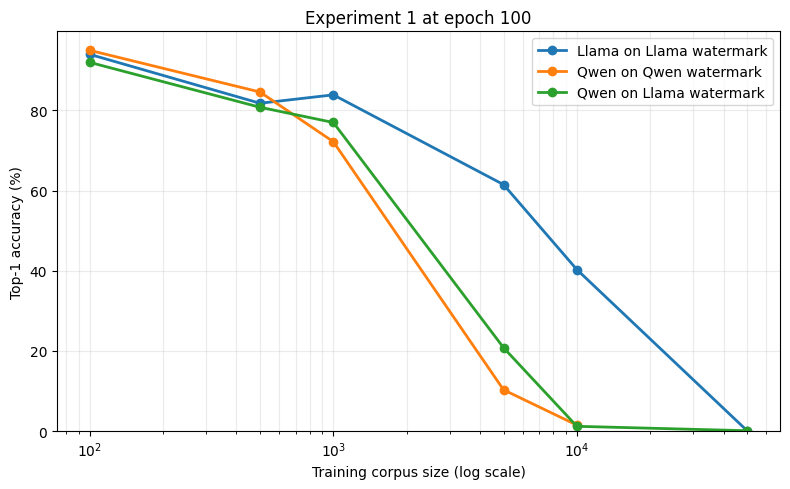

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, group in df.groupby('model', sort=False):
    ax.plot(group.corpus_size, 100 * group.top1_accuracy, marker='o', linewidth=2, label=label)

ax.set_xscale('log')
ax.set_xlabel('Training corpus size (log scale)')
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('Experiment 1 at epoch 100')
ax.set_ylim(bottom=0)
ax.grid(True, which='both', alpha=0.25)
ax.legend()
fig.tight_layout()
figure_dir = REPO_ROOT / "src/eval/figures/comparison"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "experiment1_epoch100_top1.pdf", bbox_inches="tight")
plt.show()
